## WEEK 2 - Deep Learning Foundations (PyTorch)

In [1]:
# 24-02-26

In [ ]:
! pip install numpy

In [2]:
import numpy as np
np.random.rand(2,5,1)

array([[[0.67897488],
        [0.23232719],
        [0.29685394],
        [0.93834577],
        [0.27852913]],

       [[0.57674153],
        [0.89016905],
        [0.10535327],
        [0.04976673],
        [0.34373233]]])

In [3]:
A = np.random.seed(42)
A

In [235]:
import random

random.seed(6.0) #  produce the same random o/p for multiple executions
nums = [str(random.randint(1,1000)) for i in range(1,10)]    
n = (", ".join(nums))
print(n)

813, 588, 842, 83, 497, 781, 268, 38, 1


In [4]:
# softmax calculation
import numpy as np

def softmax(z):
    exp_z = np.exp(z - np.max(z))  # e^(z-max) / sum(z-max)........(e = 2.71828)
    print(exp_z)
    return exp_z / np.sum(exp_z)

z = np.array([2.0, 1, 0.1])
print(softmax(z))

[1.         0.36787944 0.14956862]
[0.65900114 0.24243297 0.09856589]


In [2]:
z1 = np.array([2.0, 1.0, 0.1])

In [40]:
q=np.exp(z1)
q

array([7.3890561 , 2.71828183, 1.10517092])

In [41]:
s =np.sum(q)
s

11.212508845465344

In [42]:
sm = q/s
sm

array([0.65900114, 0.24243297, 0.09856589])

In [10]:
# input var.
x = 2
y = 1
# weight + bias
x1 = 0.5
b1 = 0
x2 = 0.5
b2 = 0
l_r = 0.01

#forward pass
# Hidden layer
h = max(0,x*x1 +b1)
# output layer
y_hat = x2*h +b2
loss = 0.5*(y_hat-y)**2

print("Forward pass:")
print("i/p layer:",h)
print("o/p layer:",y_hat)
print("MSE:",loss)

Forward pass:
i/p layer: 1.0
o/p layer: 0.5
MSE: 0.125


In [ ]:
pip install torch

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

# Example: simple neural network
model = nn.Sequential(
    nn.Linear(2, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Sample input
x = torch.tensor([[1.0, 2.0]])
y = torch.tensor([[1.0]])

# Forward pass
y_hat = model(x)
loss = criterion(y_hat, y)

# Backward pass (automatic!)
loss.backward()  # computes all gradients

# Update weights
optimizer.step()
optimizer.zero_grad()

In [13]:
x

tensor([[1., 2.]])

In [14]:
loss

tensor(0.4367, grad_fn=<MseLossBackward0>)

In [15]:
data = [[12,13,14,15]]
x_data = torch.tensor(data)

In [16]:
x_data

tensor([[12, 13, 14, 15]])

In [17]:
nn = torch.ones(1,5)
nn

tensor([[1., 1., 1., 1., 1.]])

In [18]:
# Neural Network
# 25-02-26

In [19]:
x = torch.Tensor

In [20]:
def activation_function(x):
    return 1/(1+torch.exp(-x))

In [21]:
# data
features = torch.randn(1,5)

weights = torch.randn_like(features)

bias = torch.randn(1,1)

In [22]:
y = activation_function(torch.matmul(features,weights.view(5,1)) + bias)

In [23]:
y

tensor([[0.3473]])

In [24]:
# Number of input units, must match number of input features
# if you have your input = (1,5) then your your input unit must match shape[1] for mm
input_l = features.shape[1]
hidden_l = 8 # It will learn 8 different feature combinations from input.
hidden_l2 = 6 # It will learn 8 different feature combinations from input.
output_l = 1
# These are just numbers that define how many neurons each layer has in your neural network.

In [25]:
w1 = torch.randn(input_l,hidden_l)
w2 = torch.randn(hidden_l,hidden_l2)
w3 = torch.randn(hidden_l2,output_l)

b1 = torch.randn(1,hidden_l)
b2 = torch.randn(1,hidden_l2)
b3 = torch.randn(1,output_l)

In [26]:
h1 = activation_function(torch.mm(features,w1)+b1)
h2 = activation_function(torch.mm(h1,w2)+b2)
output = activation_function(torch.mm(h2,w3)+b3)
# h = activation_function(torch.mm(features,w1)+1)

In [29]:
l1 = [[11,22,33],[22,33,44],[33,44,55]]
l2 = [[1,2,3]]

In [30]:
a = torch.tensor(l1)
b = torch.tensor(l2)


In [31]:
mm = torch.mm(a,b.view(3,1))
mm

tensor([[154],
        [220],
        [286]])

In [32]:
# Train a Small Neural Network (Binary Classification)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# dummy data
'''randn = Returns a tensor filled with random numbers from a normal distribution
with mean '0' and variance '1' (also called the standard normal distribution)'''

X = torch.randn(100,5)
y = torch.randint(0,2,(100,1)).float()# randint(low,high,(range))  ### high is exclusive
# converting to .float() ensures compatibility with BCELoss.

In [3]:
#model building
class SimpleNN(nn.Module):   #Instead of manually writing all weights, we use nn.Module.
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(5,5) # fully connected(dense layer)
        self.fc2 = nn.Linear(5,8)
        self.fc3 = nn.Linear(8,1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self,x):
        x = self.sigmoid(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x
        
model = SimpleNN()


In [4]:
criterion = nn.BCELoss()           # Binary Cross Entropy
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [16]:
# training loop
for epoch in range(100):

    # optimizer.zero_grad()
    # forward pass
    outputs = model(X)

    #loss
    loss = criterion(outputs,y)

    #backward pass
    loss.backward()

    #update weights
    optimizer.step()

    if (epoch+1)%10 == 0:
        print(f"Epoch:{epoch+1:3d} | Loss:{loss.item():.4f}")

Epoch: 10 | Loss:0.4251
Epoch: 20 | Loss:0.4084
Epoch: 30 | Loss:0.3973
Epoch: 40 | Loss:0.3881
Epoch: 50 | Loss:0.3913
Epoch: 60 | Loss:0.3926
Epoch: 70 | Loss:0.3858
Epoch: 80 | Loss:0.3743
Epoch: 90 | Loss:0.3616
Epoch:100 | Loss:0.3697


In [14]:
f"{loss.item():.3f}"

'0.565'

In [39]:

# Create a MLP using d2l library

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
class Mlpmodel(d2l.Classifier):
    def __init__(self,num_input,num_output,num_hidden,lr,sigma=0.1):
        super().__init__()
        self.save_hyperparameters()
        self.w1 = nn.Parameter(torch.randn(num_input,num_hidden)*sigma)
        self.b1 = nn.Parameter(torch.zeros(num_hidden))
        self.w2 = nn.Parameter(torch.randn(num_hidden,num_output)*sigma)
        self.b2 = nn.Parameter(torch.zeros(num_output))
        

In [ ]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X,a)
def sig(X):
    return 1/(1+torch.exp(-X))

In [ ]:
@d2l.add_to_class(Mlpmodel)
def forward(self, X):
    X = X.reshape((-1, self.num_input))
    H = sig(torch.matmul(X, self.w1) + self.b1)
    return torch.matmul(H, self.w2) + self.b2

In [ ]:
model = Mlpmodel(num_input=784, num_output=10, num_hidden=256, lr=0.1)
data = d2l.FashionMNIST(batch_size=256)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)
# MLP USING Sigmoid

In [ ]:
@d2l.add_to_class(Mlpmodel)
def forward(self, X):
    X = X.reshape((-1, self.num_input))
    H = relu(torch.matmul(X, self.w1) + self.b1)
    return torch.matmul(H, self.w2) + self.b2



In [ ]:
model2 = Mlpmodel(num_input=784, num_output=10, num_hidden=256, lr=0.1,sigma=0.1)
data2 = d2l.FashionMNIST(batch_size=256)
trainer2 = d2l.Trainer(max_epochs=10)
trainer2.fit(model2, data2)
# MLP Using ReLU

In [ ]:
# 26-02-26

In [ ]:
# Exercise:1
# MLP from scratch 

In [ ]:
# importing library

In [18]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

In [37]:
# dataset
X,y = make_moons(n_samples= 1000,noise = 0.2,random_state = 42)
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Convert to PyTorch tensors
# which are required for tensor operations.
X_train = torch.tensor(X_train,dtype= torch.float32)
y_train = torch.tensor(y_train,dtype= torch.float32).reshape(-1,1)
X_test = torch.tensor(X_test,dtype= torch.float32)
y_test = torch.tensor(y_test,dtype= torch.float32).reshape(-1,1)

In [35]:
class SimpleMLP:
    def __init__(self, n_input, n_hidden, n_output, activation_f):
        self.w1 = torch.randn(n_input, n_hidden, requires_grad=True)
        self.b1 = torch.randn(1, n_hidden, requires_grad=True)
        self.w2 = torch.randn(n_hidden, n_output, requires_grad=True)
        self.b2 = torch.randn(1, n_output, requires_grad=True)
        self.activation_f = activation_f
    
    def forward(self, X):
        z1 = torch.matmul(X, self.w1) + self.b1
        a1 = self.activation_f(z1)

        z2 = torch.matmul(a1, self.w2) + self.b2
        a2 = torch.sigmoid(z2)   # keep sigmoid for binary classification
        return a2

    def train(self, X, y, epochs=1000, lr=0.01):
        losses = []

        for epoch in range(epochs):

            output = self.forward(X)

            # loss = torch.mean((output - y) ** 2)  # MSE
            loss = torch.nn.functional.binary_cross_entropy(output, y) # BCE
            losses.append(loss.item())

            loss.backward()

            with torch.no_grad():
                self.w1 -= lr * self.w1.grad
                self.b1 -= lr * self.b1.grad
                self.w2 -= lr * self.w2.grad
                self.b2 -= lr * self.b2.grad

                self.w1.grad.zero_()
                self.b1.grad.zero_()
                self.w2.grad.zero_()
                self.b2.grad.zero_()

            if (epoch + 1) % 100 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

        return losses

Epoch [100/1000], Loss: 0.4966
Epoch [200/1000], Loss: 0.4186
Epoch [300/1000], Loss: 0.3780
Epoch [400/1000], Loss: 0.3544
Epoch [500/1000], Loss: 0.3395
Epoch [600/1000], Loss: 0.3296
Epoch [700/1000], Loss: 0.3227
Epoch [800/1000], Loss: 0.3178
Epoch [900/1000], Loss: 0.3141
Epoch [1000/1000], Loss: 0.3114
Loss:0.6147580146789551
Test Accuracy: 85.00%


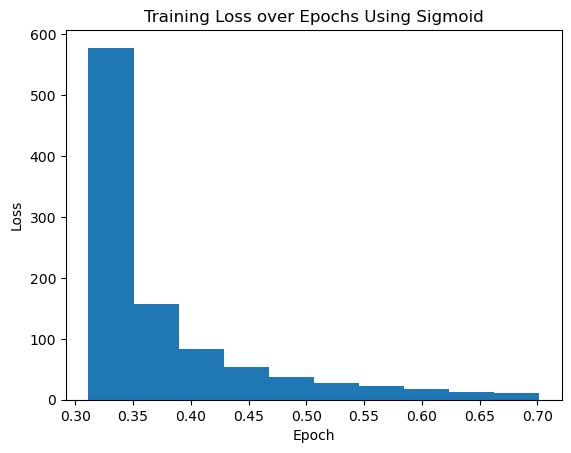

In [39]:

model = SimpleMLP(2,24,1,activation_f=torch.sigmoid)


losses = model.train(X_train,y_train,epochs= 1000,lr=0.01)
print(f"Loss:{loss}")
print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")
plt.hist(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs Using Sigmoid")

plt.show()
with torch.no_grad():
    test_output = model.forward(X_test)
    test_output = (test_output > 0.5).float() 
accuracy = torch.mean((test_output == y_test).float())

In [ ]:
model = SimpleMLP(2,4,1,activation_f=torch.tanh)

losses = model.train(X_train,y_train,epochs= 1000,lr=0.01)
plt.hist(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs Using tanh")
plt.show()
with torch.no_grad():
    test_output = model.forward(X_test)
    test_output = (test_output > 0.5).float() 
accuracy = torch.mean((test_output == y_test).float())
print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")

In [ ]:
model = SimpleMLP(2,4,1,activation_f=torch.relu)

losses = model.train(X_train,y_train,epochs= 1000,lr=0.01)
plt.hist(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs Using ReLU")
plt.show()
with torch.no_grad():
    test_output = model.forward(X_test)
    test_output = (test_output > 0.5).float() 
accuracy = torch.mean((test_output == y_test).float())
print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")

In [ ]:
X = torch.randn(100,1)
y = 3 * X + 2 + 0.1 * torch.randn(100, 1)


In [ ]:
torch.optim.SGD()

In [ ]:
#27-02-26
# optimizers in DeepLearning

Final Loss: 0.009936483576893806


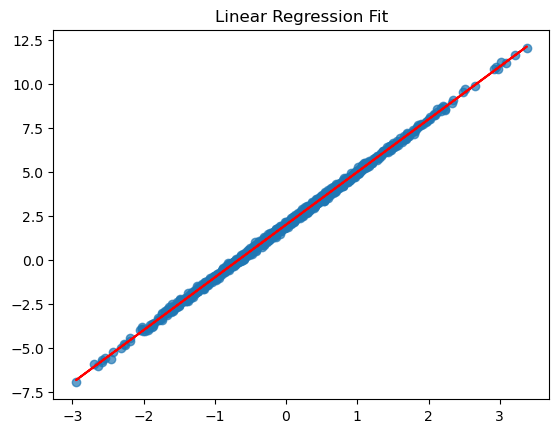

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


# dummy data
X = torch.randn(1000, 1)
y = 3 * X + 2 + 0.1 * torch.randn(1000, 1)
model = nn.Linear(1, 1)
criterion = nn.MSELoss()

# # AdamW - Optimizer
# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=1e-2,            
#     betas=(0.9, 0.999), 
#     eps=1e-8,           
#     weight_decay=0.01   
# )  

# SGD - Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01,momentum = 0.9)
losses = []
val = []
for epoch in range(1000):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
print("Final Loss:", loss.item())
with torch.no_grad():
    y_pred = model(X)
   
plt.scatter(X.numpy(), y.numpy(),alpha=0.7)
plt.plot(X.numpy(), y_pred.numpy(),c='r')
plt.title("Linear Regression Fit")
# plt.figure(figsize=(8,4))
# plt.plot(losses)

plt.show()



In [ ]:
# Exercise: 2
# train on MNIST

In [ ]:
!pip install tensorflow

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [3]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [16]:
y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [5]:
X_train.shape

(60000, 28, 28)

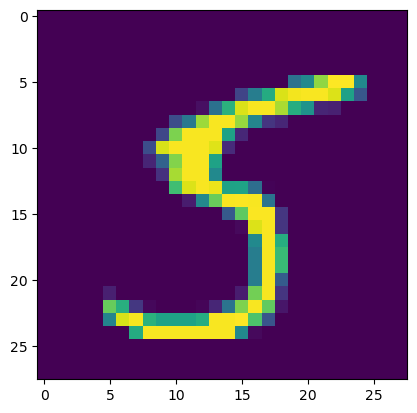

In [6]:
import matplotlib.pyplot as plt
plt.imshow(X_train[-3])
plt.show()

In [7]:
X_train, X_test = X_train / 255.0, X_test / 255.0

In [11]:
model= Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(11,activation='softmax'))
model.summary()

/home/shrutik/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-03-09 09:54:17.343142: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,971 (410.04 KB)

 Trainable params: 104,971 (410.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='SGD',metrics=['accuracy'])
history = model.fit(X_train,y_train,epochs=5,validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8165 - loss: 0.7054 - val_accuracy: 0.9052 - val_loss: 0.3408
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9069 - loss: 0.3264 - val_accuracy: 0.9221 - val_loss: 0.2743
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9223 - loss: 0.2724 - val_accuracy: 0.9336 - val_loss: 0.2397
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9322 - loss: 0.2369 - val_accuracy: 0.9428 - val_loss: 0.2129
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9401 - loss: 0.2099 - val_accuracy: 0.9459 - val_loss: 0.1975


In [11]:
X_train.shape

(60000, 28, 28)

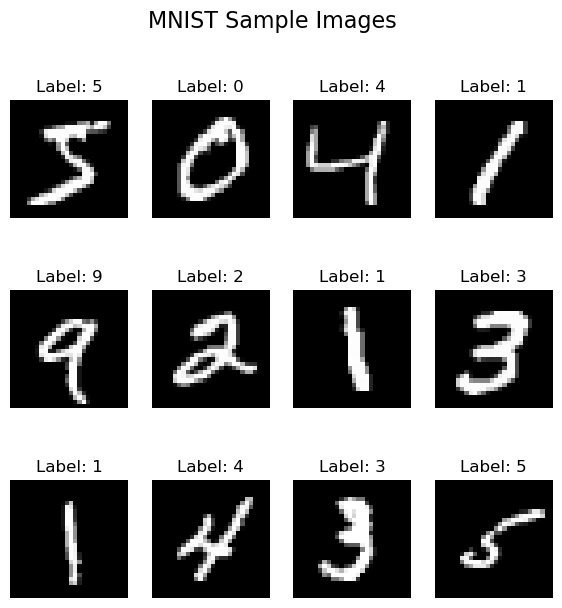

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 7))

for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')              # removes x y axis numbers, looks cleaner
plt.suptitle("MNIST Sample Images", fontsize=16)

# plt.tight_layout()
plt.show()

Epoch  100 | Train Loss: 3.3102 | Val Loss: 2.7946
Epoch  200 | Train Loss: 2.0110 | Val Loss: 1.5672
Epoch  300 | Train Loss: 1.6535 | Val Loss: 1.0796
Epoch  400 | Train Loss: 1.2952 | Val Loss: 0.8623
Epoch  500 | Train Loss: 1.3548 | Val Loss: 0.7744
Epoch  600 | Train Loss: 1.2505 | Val Loss: 0.6792
Epoch  700 | Train Loss: 1.2274 | Val Loss: 0.6671
Epoch  800 | Train Loss: 1.0797 | Val Loss: 0.6719
Epoch  900 | Train Loss: 1.0037 | Val Loss: 0.6579
Epoch 1000 | Train Loss: 0.9873 | Val Loss: 0.6559

Final Train Loss : 0.9873
Final Val Loss   : 0.6559


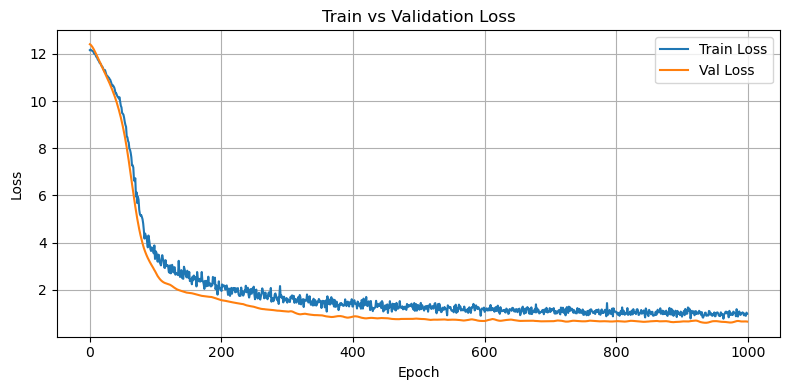

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# dummy data — non linear so dropout actually makes sense
X = torch.randn(500, 10)
y = (X[:, 0] * 3 + X[:, 1] ** 2 + 0.5 * torch.randn(500)).unsqueeze(1)

# deep model — dropout only makes sense here
model = nn.Sequential(
    nn.Linear(10, 128),
    nn.ReLU(),
    nn.Dropout(0.3),        # drops 30% neurons randomly during training
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.3),        # drops 30% neurons randomly during training
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.2),        # lighter dropout near output
    nn.Linear(32, 1)        # no dropout on output layer ever
)

criterion = nn.MSELoss()


# AdamW
# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=1e-3,
#     betas=(0.9, 0.999),
#     weight_decay=0.01
# )


# SGD
optimizer = torch.optim.SGD(
    model.parameters(),
    lr = 1e-3,
    momentum = 0.9  # Speeds up in correct direction  
                    # Momentum adds them up → bigger step → faster convergence.
)

train_losses = []
val_losses   = []

# split data into train and validation
X_train, X_val = X[:400], X[400:]
y_train, y_val = y[:400], y[400:]

for epoch in range(1000):

    # training mode — dropout is ACTIVE
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss   = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # evaluation mode — dropout is DISABLED
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)
        val_losses.append(val_loss.item())

    if (epoch+1)  % 100 == 0:
        print(f"Epoch {epoch+1:4d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

print(f"\nFinal Train Loss : {train_losses[-1]:.4f}")
print(f"Final Val Loss   : {val_losses[-1]:.4f}")

# plot loss & val curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
print(loss)

tensor(nan, grad_fn=<MseLossBackward0>)


In [17]:
# Batch Normalzation

In [1]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(10, 64),
    nn.BatchNorm1d(64),   # BatchNorm layer
    nn.ReLU(),

    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),

    nn.Linear(32, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=10, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=1, bias=True)
)


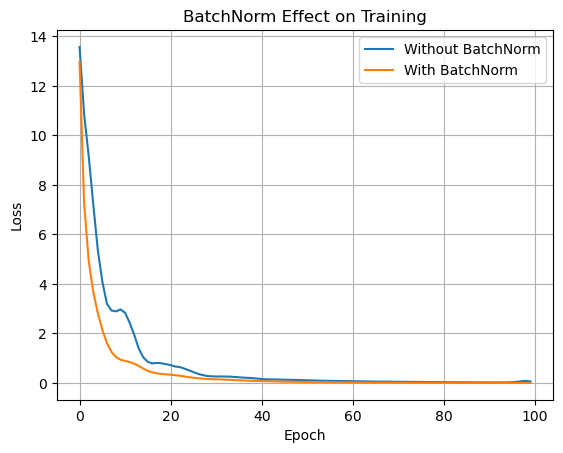

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# create synthetic nonlinear data
X = torch.randn(1000, 20)
y = (X[:, 0] * 3 + X[:, 1]**2 + 0.5 * torch.randn(1000)).unsqueeze(1)

# split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------- Model WITHOUT BatchNorm --------
model_no_bn = nn.Sequential(
    nn.Linear(20, 256),
    nn.ReLU(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

# -------- Model WITH BatchNorm --------
model_bn = nn.Sequential(
    nn.Linear(20, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

criterion = nn.MSELoss()

opt_no_bn = optim.Adam(model_no_bn.parameters(), lr=0.01)
opt_bn    = optim.Adam(model_bn.parameters(), lr=0.01)

loss_no_bn = []
loss_bn = []

for epoch in range(100):

    # ---- Train no batchnorm ----
    opt_no_bn.zero_grad()
    pred1 = model_no_bn(X_train)
    loss1 = criterion(pred1, y_train)
    loss1.backward()
    opt_no_bn.step()
    loss_no_bn.append(loss1.item())

    # ---- Train with batchnorm ----
    opt_bn.zero_grad()
    pred2 = model_bn(X_train)
    loss2 = criterion(pred2, y_train)
    loss2.backward()
    opt_bn.step()
    loss_bn.append(loss2.item())

# -------- Plot comparison --------
plt.plot(loss_no_bn, label="Without BatchNorm")
plt.plot(loss_bn, label="With BatchNorm")
plt.legend()
plt.title("BatchNorm Effect on Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [7]:
t = "nEw yEar is hEre"
t.title()


'New Year Is Here'